In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d
import glob

[bicep_curl_1.csv] Trục chính được chọn tự động: Gia tốc trục Y


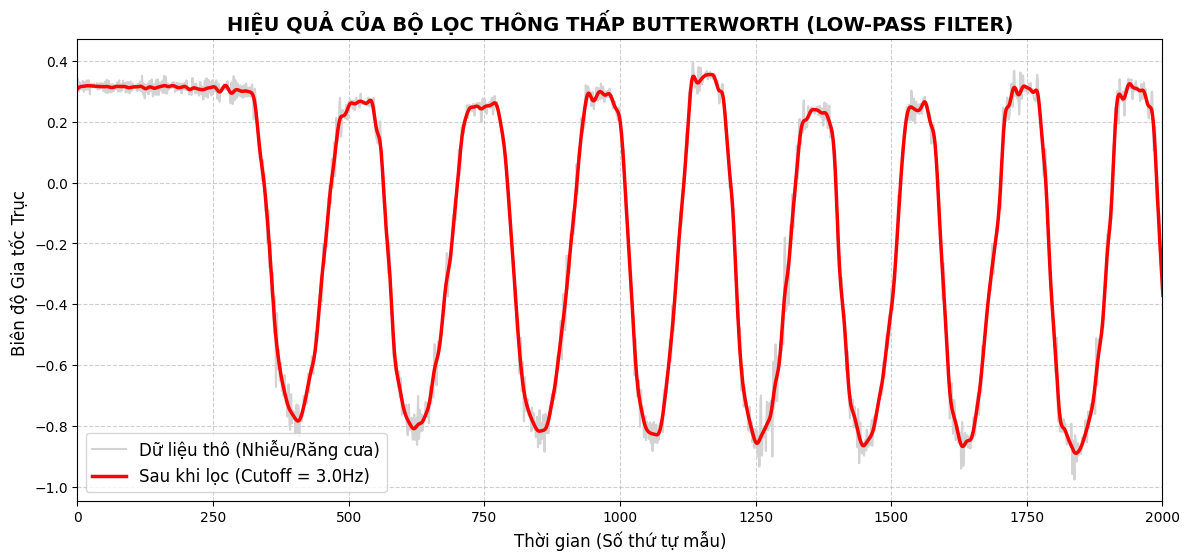

In [139]:
# ==========================================
# 0. Lọc nhiễu data bằng Low-pass-filter
# ==========================================

# Tải dữ liệu thô
df = pd.read_csv('bicep_curl_1.csv')
data_6_axis = df[['ax', 'ay', 'az', 'gx', 'gy', 'gz']].values
# Tính độ biến động (Phương sai) của 3 trục gia tốc (Cột 0, 1, 2)
variances = np.var(data_6_axis[:, 0:3], axis=0)
    
# Tìm ra Trục có biến động mạnh nhất (Trục tạo ra thung lũng sâu nhất)
best_axis_idx = np.argmax(variances)
dominant_axis = data_6_axis[:, best_axis_idx]
    
print(f"[{'bicep_curl_1.csv'}] Trục chính được chọn tự động: Gia tốc trục {'XYZ'[best_axis_idx]}")
# =========================================================

#Hàm lọc -> data đã được lọc
def butter_lowpass_filter(data, cutoff, fs, order=4):
    # Định lý Nyquist: Tần số tối đa hệ thống phân tích được bằng 1/2 Tần số lấy mẫu
    nyq = 0.5 * fs 
    normal_cutoff = cutoff / nyq # Chuẩn hóa tần số cắt
    
    # Lấy các hệ số toán học của bộ lọc (b, a)
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    
    # Tuyệt chiêu: Dùng filtfilt thay vì lfilter
    # filtfilt lọc dữ liệu 2 chiều (từ trái qua phải, rồi lộn ngược lại)
    # Giúp loại bỏ hoàn toàn hiện tượng "Trễ pha" (Phase Delay)
    data_filtered = filtfilt(b, a, data)
    
    return data_filtered

#Cấu hình thông số (Các tham số đã chốt từ lý thuyết)
fs = 50.0       # Tần số lấy mẫu: 50 mẫu/giây
cutoff = 3.0    # Tần số cắt: 3 Hz
order = 4       # Bậc 4: Cắt đủ dốc mà không làm méo tín hiệu

#Kích hoạt bộ lọc
data_filtered = butter_lowpass_filter(dominant_axis, cutoff, fs, order)

#Vẽ đồ thị so sánh trực quan
plt.figure(figsize=(14, 6))

# Vẽ dữ liệu thô (Màu xám nhạt để làm nền)
plt.plot(dominant_axis, color='lightgray', linewidth=1.5, label='Dữ liệu thô (Nhiễu/Răng cưa)')

# Vẽ dữ liệu đã lọc (Màu đỏ nổi bật)
plt.plot(data_filtered, color='red', linewidth=2.5, label=f'Sau khi lọc (Cutoff = {cutoff}Hz)')

plt.title('HIỆU QUẢ CỦA BỘ LỌC THÔNG THẤP BUTTERWORTH (LOW-PASS FILTER)', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Số thứ tự mẫu)', fontsize=12)
plt.ylabel('Biên độ Gia tốc Trục ', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Chỉ Zoom vào 300 mẫu đầu tiên (khoảng 6 giây) để nhìn thật rõ sự khác biệt
plt.xlim(0, 2000) 

plt.show()


In [134]:
# ==========================================
# 1. THUẬT TOÁN MÁY TRẠNG THÁI (STATE MACHINE)
# ==========================================
def state_machine_peak_detector(data, threshold):
    peaks = []
    valleys = []
    
    # Định nghĩa 2 trạng thái
    LOOKING_FOR_VALLEY = 0
    LOOKING_FOR_PEAK = 1
    
    # Khởi tạo trạng thái ban đầu (Giả sử ta đi tìm đáy trước)
    state = LOOKING_FOR_VALLEY 
    
    # Các biến lưu trữ giá trị cực đại/cực tiểu tạm thời
    temp_max = data[0]
    temp_max_pos = 0
    temp_min = data[0]
    temp_min_pos = 0
    
    for i in range(1, len(data)):
        val = data[i]
        
        if state == LOOKING_FOR_VALLEY:
            # Liên tục dò đáy sâu nhất
            if val < temp_min:
                temp_min = val
                temp_min_pos = i
            # Nếu đồ thị vòng lên và vượt quá Ngưỡng chênh lệch -> Chốt Đáy!
            elif val >= temp_min + threshold:
                valleys.append(temp_min_pos)
                state = LOOKING_FOR_PEAK  # Đảo trạng thái
                temp_max = val            # Reset mốc để đi tìm đỉnh mới
                temp_max_pos = i
                
        elif state == LOOKING_FOR_PEAK:
            # Liên tục dò đỉnh cao nhất
            if val > temp_max:
                temp_max = val
                temp_max_pos = i
            # Nếu đồ thị vòng xuống và vượt quá Ngưỡng chênh lệch -> Chốt Đỉnh!
            elif val <= temp_max - threshold:
                peaks.append(temp_max_pos)
                state = LOOKING_FOR_VALLEY # Đảo trạng thái
                temp_min = val             # Reset mốc để đi tìm đáy mới
                temp_min_pos = i
        
    # Sau khi chạy hết dữ liệu, nếu máy đang kẹt ở trạng thái TÌM ĐỈNH
    if state == LOOKING_FOR_PEAK:
        peaks.append(temp_max_pos) # Ép chốt sổ cái đỉnh cuối cùng!
        
    # Ngược lại, nếu người dùng đeo ngược cảm biến và kẹt ở TÌM ĐÁY
    elif state == LOOKING_FOR_VALLEY and len(peaks) > len(valleys):
        valleys.append(temp_min_pos)
    # --------------------------------------------

    return peaks, valleys
    

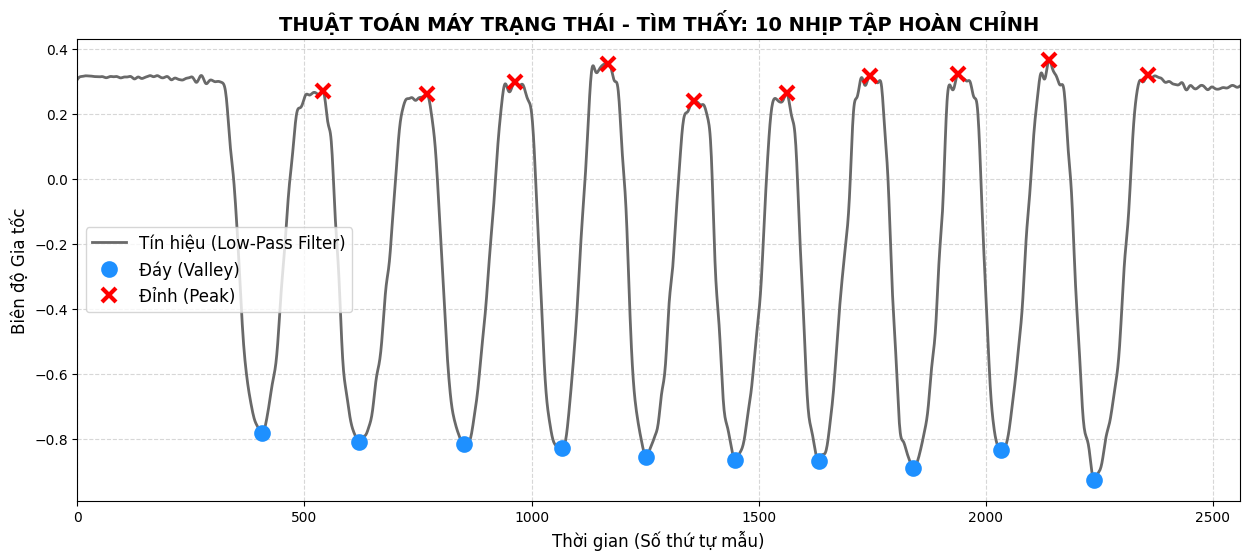

In [135]:
# ==========================================
# 2. THỰC THI & TÍNH TOÁN
# ==========================================
# Ngưỡng chênh lệch (Hysteresis Threshold): 
# Đồ thị của bạn rơi từ ~0.4 xuống -0.8 (chênh lệch 1.2G). 
# Chọn THRESHOLD = 0.6 là mức an toàn để lọc sạch các rung lắc nhỏ.
THRESHOLD = 0.6

peaks, valleys = state_machine_peak_detector(data_filtered, THRESHOLD)

# Tính số nhịp tập 
rep_count = min(len(peaks), len(valleys))

# ==========================================
# 3. VẼ ĐỒ THỊ KIỂM CHỨNG
# ==========================================
plt.figure(figsize=(15, 6))

# Vẽ đồ thị đã lọc nhiễu
plt.plot(data_filtered, color='dimgray', linewidth=2, label='Tín hiệu (Low-Pass Filter)')

# Đánh dấu Đáy (Valleys) bằng chấm Tròn Xanh
plt.plot(valleys, data_filtered[valleys], "o", color='dodgerblue', markersize=10, markeredgewidth=2, label='Đáy (Valley)')

# Đánh dấu Đỉnh (Peaks) bằng chữ X Đỏ
plt.plot(peaks, data_filtered[peaks], "x", color='red', markersize=10, markeredgewidth=3, label='Đỉnh (Peak)')

plt.title(f'THUẬT TOÁN MÁY TRẠNG THÁI - TÌM THẤY: {rep_count} NHỊP TẬP HOÀN CHỈNH', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Số thứ tự mẫu)', fontsize=12)
plt.ylabel('Biên độ Gia tốc', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xlim(0, len(dominant_axis)) 
plt.show()

✅ Kích thước Ma trận Dataset: (9, 100, 6)
-> Gồm 9 nhịp tập, mỗi nhịp đúng 100 mẫu x 6 Trục.


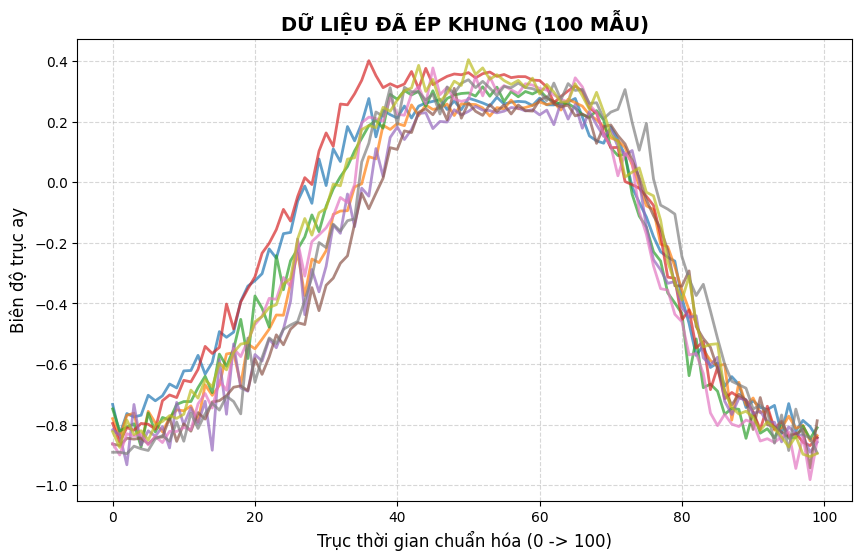

In [136]:
# ==========================================
# THUẬT TOÁN CẮT CỬA SỔ & NỘI SUY (RESAMPLING)
# ==========================================
def extract_and_resample_windows(data_matrix, valleys, target_length=100):
    """
    Cắt dữ liệu từ Đáy đến Đáy và ép về cùng kích thước target_length
    """
    windows = []
    if len(data_matrix.shape) == 1:
        data_matrix = data_matrix.reshape(-1, 1)

    # Duyệt qua từng cặp Đáy liên tiếp
    for i in range(len(valleys) - 1):
        start_idx = valleys[i]
        end_idx = valleys[i+1]
        
        # 1. Cắt đoạn dữ liệu thô (Độ dài thay đổi)
        raw_window = data_matrix[start_idx:end_idx, :]
        current_length = len(raw_window)
        
        # Bỏ qua nếu nhiễu cắt ra quá ngắn (< 20 mẫu)
        # if current_length < 20: 
        #     continue
            
        # 2. Thuật toán Nội suy (Interpolation)
        # Tạo trục thời gian cũ (từ 0 đến current_length - 1)
        old_time = np.linspace(0, current_length - 1, current_length)
        
        # Tạo phương trình hàm số cho đoạn dữ liệu này (Cubic Spline)
        f = interp1d(old_time, raw_window, kind='cubic', axis=0)
        
        # Tạo trục thời gian mới có ĐÚNG 100 điểm
        new_time = np.linspace(0, current_length - 1, target_length)
        
        # Tính toán giá trị Y mới dựa trên trục thời gian 100 điểm
        resampled_window = f(new_time)
        
        # # 3. Chuẩn hóa Biên độ (Min-Max Scaling) từ 0 đến 1
        # # Giúp AI học nhanh hơn và không bị phụ thuộc vào lực vung tay mạnh/yếu
        # min_val = np.min(resampled_window)
        # max_val = np.max(resampled_window)
        # normalized_window = (resampled_window - min_val) / (max_val - min_val)
        
        windows.append(resampled_window)
        
    # Chuyển list thành Numpy Array 2 chiều (Ma trận chuẩn cho Deep Learning)
    return np.array(windows)

# ==========================================
# THỰC THI VÀ VẼ ĐỒ THỊ
# ==========================================

# Gọi hàm ép khung về đúng 100 timestep
AI_ready_dataset = extract_and_resample_windows(data_6_axis, valleys, target_length=100)

# LƯỚI AN TOÀN TRÁNH VĂNG LỖI INDEXERROR
if AI_ready_dataset.size == 0 or len(AI_ready_dataset.shape) < 3:
    print("❌ CẢNH BÁO: Không tìm thấy nhịp tập nào! Máy trạng thái không hoạt động.")
    print("-> Hãy cuộn lên Cell 4 và kiểm tra xem đồ thị có xuất hiện các chấm xanh/đỏ chưa.")
else:
    print(f"✅ Kích thước Ma trận Dataset: {AI_ready_dataset.shape}")
    print(f"-> Gồm {AI_ready_dataset.shape[0]} nhịp tập, mỗi nhịp đúng {AI_ready_dataset.shape[1]} mẫu x 6 Trục.")

# Vẽ tất cả các nhịp chồng lên nhau để kiểm tra "Form"
plt.figure(figsize=(10, 6))
for i in range(AI_ready_dataset.shape[0]):
    plt.plot(AI_ready_dataset[i, : , 1], alpha=0.7, linewidth=2, label=f'Nhịp {i+1}')

plt.title('DỮ LIỆU ĐÃ ÉP KHUNG (100 MẪU)', fontsize=14, fontweight='bold')
plt.xlabel('Trục thời gian chuẩn hóa (0 -> 100)', fontsize=12)
plt.ylabel('Biên độ trục ay', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [137]:
import glob
import numpy as np
import pandas as pd

# Khởi tạo giỏ hàng trống để chứa ma trận của từng file
X_list = []
y_list = []

# Thông số chuẩn dùng chung
THRESHOLD = 0.6 
fs = 50.0       
cutoff = 3.0    
order = 4 

print("====== ĐANG XỬ LÝ CLASS 1 (ĐÚNG FORM) ======")
# Tìm tất cả file đúng form (từ 1 đến 6)
class_1_files = glob.glob('bicep_curl_*.csv')

for file_path in class_1_files:
    # 1. Đọc dữ liệu & Chọn trục thủ lĩnh
    df = pd.read_csv(file_path)
    data_6_axis = df[['ax', 'ay', 'az', 'gx', 'gy', 'gz']].values
    variances = np.var(data_6_axis[:, 0:3], axis=0)
    dominant_axis = data_6_axis[:, np.argmax(variances)]
    
    # 2. Lọc -> Tìm mốc -> Cắt (Tái sử dụng các hàm bạn đã định nghĩa ở trên!)
    data_filtered = butter_lowpass_filter(dominant_axis, cutoff, fs, order)
    peaks, valleys = state_machine_peak_detector(data_filtered, THRESHOLD)
    X_temp = extract_and_resample_windows(data_6_axis, valleys, target_length=100)
    
    # 3. Gán nhãn
    if X_temp.size > 0 and len(X_temp.shape) == 3:
        print(f"✅ {file_path}: Cắt được {X_temp.shape[0]} nhịp.")
        X_list.append(X_temp)
        y_list.append(np.ones(X_temp.shape[0])) # Nhãn 1 (Đúng Form)
    else:
        print(f"❌ {file_path}: Không cắt được nhịp nào hoặc bị nhiễu.")

print("\n====== ĐANG XỬ LÝ CLASS 0 (SAI FORM & IDLE) ======")
# Tìm tất cả file sai form (wrong 1-3) và file nghỉ (idle 1-5)
class_0_files = glob.glob('wrong_bicep_curl_*.csv') + glob.glob('idle_*.csv')

for file_path in class_0_files:
    # 1. Đọc dữ liệu & Chọn trục thủ lĩnh
    df = pd.read_csv(file_path)
    data_6_axis = df[['ax', 'ay', 'az', 'gx', 'gy', 'gz']].values
    variances = np.var(data_6_axis[:, 0:3], axis=0)
    dominant_axis = data_6_axis[:, np.argmax(variances)]
    
    # 2. Lọc -> Tìm mốc -> Cắt 
    data_filtered = butter_lowpass_filter(dominant_axis, cutoff, fs, order)
    peaks, valleys = state_machine_peak_detector(data_filtered, THRESHOLD)
    X_temp = extract_and_resample_windows(data_6_axis, valleys, target_length=100)
    
    # 3. Gán nhãn
    if X_temp.size > 0 and len(X_temp.shape) == 3:
        print(f"✅ {file_path}: Cắt được {X_temp.shape[0]} nhịp.")
        X_list.append(X_temp)
        y_list.append(np.zeros(X_temp.shape[0])) # Nhãn 0 (Sai Form/Idle)
    else:
        print(f"ℹ️ {file_path}: Không bắt được nhịp (Rất tốt, vì đây là file idle).")

# ==========================================
# GỘP TẤT CẢ VÀ LƯU TRỮ DATASET
# ==========================================
if len(X_list) > 0:
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    
    print("\n🎉 HOÀN THÀNH TỔNG HỢP DỮ LIỆU!")
    print(f"-> Tổng số nhịp (Samples): {X.shape[0]}")
    print(f"-> Kích thước Tensor X: {X.shape} (Samples, Timesteps, Channels)")
    print(f"-> Kích thước Label y: {y.shape}")
    
    # Lưu ra 2 file cứng để train AI
    np.save('X_dataset.npy', X)
    np.save('y_dataset.npy', y)
    print("\n💾 Đã lưu thành công 2 file 'X_dataset.npy' và 'y_dataset.npy'.")
else:
    print("❌ Lỗi: Không có dữ liệu nào được trích xuất.")

====== ĐANG XỬ LÝ CLASS 1 (ĐÚNG FORM) ======
✅ bicep_curl_1.csv: Cắt được 9 nhịp.
✅ bicep_curl_2.csv: Cắt được 9 nhịp.
✅ bicep_curl_3.csv: Cắt được 9 nhịp.
✅ bicep_curl_4.csv: Cắt được 14 nhịp.
✅ bicep_curl_5.csv: Cắt được 14 nhịp.
✅ bicep_curl_6.csv: Cắt được 14 nhịp.

====== ĐANG XỬ LÝ CLASS 0 (SAI FORM & IDLE) ======
✅ wrong_bicep_curl_1.csv: Cắt được 18 nhịp.
✅ wrong_bicep_curl_2.csv: Cắt được 17 nhịp.
✅ wrong_bicep_curl_3.csv: Cắt được 11 nhịp.
ℹ️ idle_1.csv: Không bắt được nhịp (Rất tốt, vì đây là file idle).
✅ idle_2.csv: Cắt được 1 nhịp.
ℹ️ idle_3.csv: Không bắt được nhịp (Rất tốt, vì đây là file idle).
✅ idle_4.csv: Cắt được 2 nhịp.
✅ idle_5.csv: Cắt được 11 nhịp.

🎉 HOÀN THÀNH TỔNG HỢP DỮ LIỆU!
-> Tổng số nhịp (Samples): 129
-> Kích thước Tensor X: (129, 100, 6) (Samples, Timesteps, Channels)
-> Kích thước Label y: (129,)

💾 Đã lưu thành công 2 file 'X_dataset.npy' và 'y_dataset.npy'.
